In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import random
from datetime import datetime, timedelta

# -----------------------------
# Configuration
# -----------------------------
START_TIME = datetime(2025, 11, 12, 12, 8, 0)
NUM_PACKETS = 300
OUTPUT_PATH = "/kaggle/working/synthetic_sensor_logs.txt"

SOIL_SENDERS = [0, 1, 2, 3, 4]
PRESSURE_SENDER = 101

MOISTURE_BASE = [38, 75, 48, 44, 35]
TEMP_BASE = 24.5
PRESSURE_BASE = -65.0

# -----------------------------
# Calibration (unknown to model)
# -----------------------------
def sample_gain():
    return np.random.normal(1.0, 0.05)

def sample_bias(scale):
    return np.random.normal(0.0, scale)

CALIBRATION = {}
for s in SOIL_SENDERS:
    CALIBRATION[s] = {
        "M1": (sample_gain(), sample_bias(5)),
        "M2": (sample_gain(), sample_bias(5)),
        "T1": (sample_gain(), sample_bias(0.7)),
        "T2": (sample_gain(), sample_bias(0.7)),
    }

CALIBRATION[PRESSURE_SENDER] = {
    "P": (sample_gain(), sample_bias(8))
}

# -----------------------------
# Latent states
# -----------------------------
latent_moisture = {s: MOISTURE_BASE[i] for i, s in enumerate(SOIL_SENDERS)}
latent_temp = TEMP_BASE
latent_pressure = PRESSURE_BASE

# -----------------------------
# Helpers
# -----------------------------
def apply_calibration(value, gain, bias, noise=0.05):
    return gain * value + bias + np.random.normal(0, noise)

def rain_event():
    if random.random() < 0.1:
        return random.choice([500, 1200, 3000, 8000])
    return 0.0

# -----------------------------
# Ground-truth collector (FOR EVALUATION ONLY)
# -----------------------------
truth_records = []
np.random.seed(42)
random.seed(42)

# -----------------------------
# Write logs (NO print)
# -----------------------------
current_time = START_TIME

with open(OUTPUT_PATH, "w") as f:
    for pkt_id in range(NUM_PACKETS):

        # async time
        current_time += timedelta(seconds=random.randint(40, 300))

        sender = random.choices(
            SOIL_SENDERS + [PRESSURE_SENDER],
            weights=[1, 1, 1, 1, 1, 0.7]
        )[0]

        if sender in SOIL_SENDERS:
            rain = rain_event()
            latent_moisture[sender] += 0.002 * rain - np.random.normal(0, 0.3)
            latent_temp += np.random.normal(0, 0.03)

            # ---- store ground truth (soil node) ----
            truth_records.append([
                current_time, sender, "moisture", latent_moisture[sender]
            ])
            truth_records.append([
                current_time, sender, "temperature", latent_temp
            ])


            sm1 = apply_calibration(
                latent_moisture[sender], *CALIBRATION[sender]["M1"]
            )
            sm2 = apply_calibration(
                latent_moisture[sender], *CALIBRATION[sender]["M2"]
            )
            st1 = apply_calibration(
                latent_temp, *CALIBRATION[sender]["T1"], noise=0.02
            )
            st2 = apply_calibration(
                latent_temp, *CALIBRATION[sender]["T2"], noise=0.02
            )

            log = (
                f"{current_time.strftime('%Y-%m-%d %H:%M:%S')},"
                f"{pkt_id},"
                f"Received packet 'Sender {sender}:,0, "
                f"S{sender}M1: ,{sm1:.2f},"
                f"S{sender}M2: ,{sm2:.2f},"
                f"S{sender}T1: ,{st1:.2f},"
                f"S{sender}T2: ,{st2:.2f},"
                f"DepthOfRain: ,{rain:.2f}'"
            )

        else:
            latent_pressure += np.random.normal(-0.3, 0.5)
            # ---- store ground truth (pressure node) ----
            truth_records.append([
                current_time, 101, "pressure", latent_pressure
            ])

            pressure = apply_calibration(
                latent_pressure, *CALIBRATION[PRESSURE_SENDER]["P"], noise=0.2
            )

            log = (
                f"{current_time.strftime('%Y-%m-%d %H:%M:%S')},"
                f"{pkt_id},"
                f"Received packet 'Sender 101:,Pressure_kPa: ,{pressure:.2f}'"
            )

        # 🔴 THIS is where print(log) used to be
        f.write(log + "\n")

# optional sanity message (comment out if you want zero output)
# print(f"Saved synthetic logs to {OUTPUT_PATH}")


In [3]:
# -----------------------------
# Save ground truth (DO NOT PRINT)
# -----------------------------
df_true_raw = pd.DataFrame(
    truth_records,
    columns=["timestamp", "sender", "modality", "value"]
)

df_true_raw.to_csv(
    "/kaggle/working/synthetic_ground_truth.csv",
    index=False
)


In [4]:
import os

path = "/kaggle/working/synthetic_sensor_logs.txt"
print("File exists:", os.path.exists(path))
print("File size (MB):", os.path.getsize(path) / 1e6)


File exists: True
File size (MB): 0.036076


In [5]:
with open(path, "r") as f:
    for _ in range(5):
        print(f.readline().strip())


2025-11-12 12:09:37,0,Received packet 'Sender 0:,0, S0M1: ,47.16,S0M2: ,42.06,S0T1: ,26.74,S0T2: ,22.68,DepthOfRain: ,0.00'
2025-11-12 12:12:11,1,Received packet 'Sender 0:,0, S0M1: ,46.68,S0M2: ,41.52,S0T1: ,26.76,S0T2: ,22.69,DepthOfRain: ,0.00'
2025-11-12 12:13:35,2,Received packet 'Sender 3:,0, S3M1: ,39.66,S3M2: ,52.74,S3T1: ,24.79,S3T2: ,23.48,DepthOfRain: ,500.00'
2025-11-12 12:16:06,3,Received packet 'Sender 1:,0, S1M1: ,80.17,S1M2: ,74.05,S1T1: ,25.51,S1T2: ,24.93,DepthOfRain: ,0.00'
2025-11-12 12:18:27,4,Received packet 'Sender 4:,0, S4M1: ,35.13,S4M2: ,35.10,S4T1: ,24.48,S4T2: ,24.79,DepthOfRain: ,0.00'


In [6]:
import re
import pandas as pd

rows = []

pattern_soil = re.compile(
    r"Sender (\d+):,0, "
    r"S\d+M1: ,([\d\.\-]+),"
    r"S\d+M2: ,([\d\.\-]+),"
    r"S\d+T1: ,([\d\.\-]+),"
    r"S\d+T2: ,([\d\.\-]+),"
    r"DepthOfRain: ,([\d\.\-]+)"
)

pattern_pressure = re.compile(
    r"Sender 101:,Pressure_kPa: ,([\d\.\-]+)"
)

with open(path, "r") as f:
    for line in f:
        ts, pkt, payload = line.split(",", 2)

        if "Pressure_kPa" in payload:
            m = pattern_pressure.search(payload)
            rows.append([ts, 101, "pressure", "P", float(m.group(1))])
        else:
            m = pattern_soil.search(payload)
            sender = int(m.group(1))
            rows.extend([
                [ts, sender, "moisture", "M1", float(m.group(2))],
                [ts, sender, "moisture", "M2", float(m.group(3))],
                [ts, sender, "temperature", "T1", float(m.group(4))],
                [ts, sender, "temperature", "T2", float(m.group(5))],
                [ts, sender, "rain", "R", float(m.group(6))],
            ])

df = pd.DataFrame(rows, columns=["timestamp", "sender", "modality", "probe", "value"])


In [7]:
df_m = df[df.modality == "moisture"]
pivot = df_m.pivot_table(
    index=["timestamp", "sender"],
    columns="probe",
    values="value"
).dropna()

print("Mean |M1 − M2|:", (pivot["M1"] - pivot["M2"]).abs().mean())


Mean |M1 − M2|: 7.364905660377358


In [8]:
df_t = df[df.modality == "temperature"]
pivot_t = df_t.pivot_table(
    index=["timestamp", "sender"],
    columns="probe",
    values="value"
).dropna()

print("Mean |T1 − T2|:", (pivot_t["T1"] - pivot_t["T2"]).abs().mean())


Mean |T1 − T2|: 1.7501132075471697


In [9]:
df_p = df[df.modality == "pressure"]
print(df_p["value"].describe())


count    35.000000
mean    -78.694286
std       4.781395
min     -86.080000
25%     -83.800000
50%     -77.960000
75%     -74.570000
max     -71.050000
Name: value, dtype: float64


In [10]:
df_r = df[df.modality == "rain"]
print(df_r["value"].value_counts().head(10))


value
0.0       241
500.0       9
3000.0      8
8000.0      5
1200.0      2
Name: count, dtype: int64


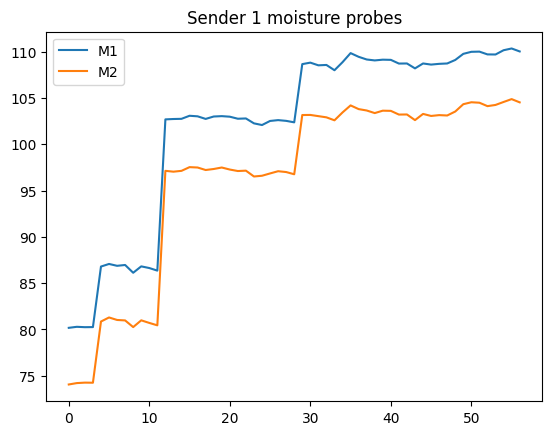

In [11]:
import matplotlib.pyplot as plt

sample_sender = 1
sample = df[(df.sender == sample_sender) & (df.modality == "moisture")]

for probe in ["M1", "M2"]:
    plt.plot(sample[sample.probe == probe]["value"].values, label=probe)

plt.legend()
plt.title(f"Sender {sample_sender} moisture probes")
plt.show()


In [12]:
import re
import pandas as pd
from datetime import datetime

# -----------------------------
# Regex patterns (STRICT)
# -----------------------------
SOIL_PATTERN = re.compile(
    r"Sender (?P<sender>\d+):,0,\s*"
    r"S\d+M1:\s*,(?P<M1>[-\d\.]+),"
    r"S\d+M2:\s*,(?P<M2>[-\d\.]+),"
    r"S\d+T1:\s*,(?P<T1>[-\d\.]+),"
    r"S\d+T2:\s*,(?P<T2>[-\d\.]+),"
    r"DepthOfRain:\s*,(?P<R>[-\d\.]+)"
)

PRESSURE_PATTERN = re.compile(
    r"Sender 101:,Pressure_kPa:\s*,(?P<P>[-\d\.]+)"
)

# -----------------------------
# Parser
# -----------------------------
def parse_sensor_logs(
    filepath: str,
    strict: bool = False
):
    """
    Production parser for soil + pressure sensor logs.

    Parameters
    ----------
    filepath : str
        Path to log file
    strict : bool
        If True, raises on malformed lines.
        If False, records them in error_log.

    Returns
    -------
    df : pd.DataFrame
        Canonical long-format dataset
    error_log : list
        List of (line_number, line, reason)
    """

    records = []
    error_log = []

    with open(filepath, "r") as f:
        for line_num, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            try:
                # split transport metadata
                ts_str, pkt_id, payload = line.split(",", 2)
                timestamp = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S")
                packet_id = int(pkt_id)

                # pressure packet
                if "Pressure_kPa" in payload:
                    m = PRESSURE_PATTERN.search(payload)
                    if not m:
                        raise ValueError("Pressure regex failed")

                    records.append([
                        timestamp, packet_id, 101,
                        "pressure", "P", float(m.group("P"))
                    ])

                # soil packet
                else:
                    m = SOIL_PATTERN.search(payload)
                    if not m:
                        raise ValueError("Soil regex failed")

                    sender = int(m.group("sender"))

                    records.extend([
                        [timestamp, packet_id, sender, "moisture", "M1", float(m.group("M1"))],
                        [timestamp, packet_id, sender, "moisture", "M2", float(m.group("M2"))],
                        [timestamp, packet_id, sender, "temperature", "T1", float(m.group("T1"))],
                        [timestamp, packet_id, sender, "temperature", "T2", float(m.group("T2"))],
                        [timestamp, packet_id, sender, "rain", "R", float(m.group("R"))],
                    ])

            except Exception as e:
                if strict:
                    raise
                error_log.append((line_num, line, str(e)))

    df = pd.DataFrame(
        records,
        columns=["timestamp", "packet_id", "sender", "modality", "probe", "value"]
    )

    return df, error_log


In [13]:
path = "/kaggle/working/synthetic_sensor_logs.txt"

df, errors = parse_sensor_logs(path)

print("Parsed rows:", len(df))
print("Errors:", len(errors))


Parsed rows: 1360
Errors: 0


In [14]:
import pandas as pd

def add_time_index(df, window_minutes=5):
    df = df.copy()
    t0 = df["timestamp"].min()
    delta = pd.to_timedelta(window_minutes, unit="min")
    df["time_index"] = ((df["timestamp"] - t0) // delta).astype(int)
    return df


In [15]:
print(df.columns.tolist())


['timestamp', 'packet_id', 'sender', 'modality', 'probe', 'value']


In [16]:
import pandas as pd

def add_time_index(df, window_minutes=5):
    df = df.copy()
    t0 = df["timestamp"].min()
    delta = pd.to_timedelta(window_minutes, unit="min")
    df["time_index"] = ((df["timestamp"] - t0) // delta).astype(int)
    return df

df = add_time_index(df, window_minutes=5)


In [17]:
print(df.columns.tolist())
print(df[["timestamp", "time_index"]].head())


['timestamp', 'packet_id', 'sender', 'modality', 'probe', 'value', 'time_index']
            timestamp  time_index
0 2025-11-12 12:09:37           0
1 2025-11-12 12:09:37           0
2 2025-11-12 12:09:37           0
3 2025-11-12 12:09:37           0
4 2025-11-12 12:09:37           0


In [18]:
df_t = (
    df
    .groupby(
        ["time_index", "sender", "modality", "probe"],
        as_index=False
    )
    .agg({"value": "mean"})
)


In [19]:
df_t.head()


,time_index,sender,modality,probe,value
0,0,0,moisture,M1,46.920
1,0,0,moisture,M2,41.790
2,0,0,rain,R,0.000
3,0,0,temperature,T1,26.750
4,0,0,temperature,T2,22.685


In [20]:
NODE_IDS = [0, 1, 2, 3, 4, 101]
NODE_TO_IDX = {nid: i for i, nid in enumerate(NODE_IDS)}
IDX_TO_NODE = {i: nid for nid, i in NODE_TO_IDX.items()}
NUM_NODES = len(NODE_IDS)


In [21]:
import numpy as np

A = np.ones((NUM_NODES, NUM_NODES), dtype=np.float32)


In [22]:
D_inv_sqrt = np.diag(1.0 / np.sqrt(A.sum(axis=1)))
A_norm = D_inv_sqrt @ A @ D_inv_sqrt


In [23]:
print("Adjacency shape:", A.shape)
print("Self loops:", np.diag(A))
print("Symmetric:", np.allclose(A, A.T))


Adjacency shape: (6, 6)
Self loops: [1. 1. 1. 1. 1. 1.]
Symmetric: True


In [24]:
import pandas as pd
import numpy as np

def to_wide(df_t):
    """
    Converts long-format data into
    (time_index, sender) → columns per probe
    """
    wide = (
        df_t
        .pivot_table(
            index=["time_index", "sender"],
            columns=["modality", "probe"],
            values="value"
        )
        .sort_index()
    )
    return wide


In [25]:
def ema(series, alpha=0.3):
    return series.ewm(alpha=alpha, adjust=False).mean()


In [26]:
def baseline_estimator(wide_df, alpha=0.3):
    outputs = []

    for sender in wide_df.index.get_level_values("sender").unique():
        df_s = wide_df.xs(sender, level="sender")

        # Moisture
        if ("moisture", "M1") in df_s and ("moisture", "M2") in df_s:
            moist = df_s[[("moisture", "M1"), ("moisture", "M2")]].mean(axis=1)
            moist_hat = ema(moist, alpha)

            outputs.append(pd.DataFrame({
                "time_index": moist_hat.index,
                "sender": sender,
                "modality": "moisture",
                "estimate": moist_hat.values
            }))

        # Temperature
        if ("temperature", "T1") in df_s and ("temperature", "T2") in df_s:
            temp = df_s[[("temperature", "T1"), ("temperature", "T2")]].mean(axis=1)
            temp_hat = ema(temp, alpha)

            outputs.append(pd.DataFrame({
                "time_index": temp_hat.index,
                "sender": sender,
                "modality": "temperature",
                "estimate": temp_hat.values
            }))

        # Pressure (only sender 101)
        if sender == 101 and ("pressure", "P") in df_s:
            press_hat = ema(df_s[("pressure", "P")], alpha)

            outputs.append(pd.DataFrame({
                "time_index": press_hat.index,
                "sender": sender,
                "modality": "pressure",
                "estimate": press_hat.values
            }))

    return pd.concat(outputs, ignore_index=True)


In [27]:
wide = to_wide(df_t)
baseline_out = baseline_estimator(wide, alpha=0.3)

baseline_out.head()


,time_index,sender,modality,estimate
0,0,0,moisture,44.355000
1,4,0,moisture,44.247000
2,6,0,moisture,44.175900
3,8,0,moisture,44.100630
4,10,0,moisture,44.056941


In [28]:
import numpy as np

def rmse(df_true, df_hat, modality):
    merged = df_true[df_true.modality == modality].merge(
        df_hat[df_hat.modality == modality],
        on=["time_index", "sender"],
        suffixes=("_true", "_hat")
    )
    return np.sqrt(
        np.mean((merged.value_hat - merged.value_true) ** 2)
    )


In [29]:
def probe_disagreement(df, modality):
    pivot = (
        df[df.modality == modality]
        .pivot_table(
            index=["time_index", "sender"],
            columns="probe",
            values="value"
        )
        .dropna()
    )
    return (pivot.iloc[:, 0] - pivot.iloc[:, 1]).abs().mean()


In [30]:
def fault_penalty(df_true, df_hat, fault_times, modality):
    clean = ~df_true.time_index.isin(fault_times)
    fault = df_true.time_index.isin(fault_times)

    rmse_clean = rmse(df_true[clean], df_hat, modality)
    rmse_fault = rmse(df_true[fault], df_hat, modality)

    return rmse_fault - rmse_clean


In [31]:
def smoothness(df_hat, modality):
    diffs = []
    for sender in df_hat.sender.unique():
        s = (
            df_hat[
                (df_hat.sender == sender) &
                (df_hat.modality == modality)
            ]
            .sort_values("time_index")
            .estimate
            .diff()
            .dropna()
        )
        diffs.append(s.abs().mean())
    return np.mean(diffs)


In [32]:
df_hat = baseline_out.rename(columns={"estimate": "value"})


In [33]:
import numpy as np

def rmse(df_true, df_hat, modality):
    merged = (
        df_true[df_true.modality == modality]
        .merge(
            df_hat[df_hat.modality == modality],
            on=["time_index", "sender"],
            suffixes=("_true", "_hat")
        )
    )
    return np.sqrt(
        np.mean((merged.value_hat - merged.value_true) ** 2)
    )


In [34]:
df_true = pd.read_csv(
    "/kaggle/working/synthetic_ground_truth.csv",
    parse_dates=["timestamp"]
)

df_true = add_time_index(df_true, window_minutes=5)

df_true = (
    df_true
    .groupby(["time_index", "sender", "modality"], as_index=False)
    .agg({"value": "mean"})
)


In [35]:
print(df_true.head())
print(df_hat.head())


   time_index  sender     modality      value
0           0       0     moisture  37.614104
1           0       0  temperature  24.507364
2           0       3     moisture  44.927411
3           0       3  temperature  24.461477
4           1       1     moisture  75.272407
   time_index  sender  modality      value
0           0       0  moisture  44.355000
1           4       0  moisture  44.247000
2           6       0  moisture  44.175900
3           8       0  moisture  44.100630
4          10       0  moisture  44.056941


In [36]:
for m in ["moisture", "temperature", "pressure"]:
    print(m, rmse(df_true, df_hat, m))


moisture 3.3696462247352064
temperature 0.4255971060250684
pressure 4.123066145146685


In [37]:
wide = to_wide(df_t)


In [38]:
import numpy as np
import pandas as pd

def fit_calibration(df_s, probes):
    """
    Fits alpha, beta for each probe assuming shared latent signal.
    """
    Y = df_s[probes].dropna()

    if len(Y) < 5:
        return None

    # latent estimate = mean (initial)
    theta_hat = Y.mean(axis=1).values

    params = {}
    for p in probes:
        y = Y[p].values
        A = np.vstack([theta_hat, np.ones_like(theta_hat)]).T
        alpha, beta = np.linalg.lstsq(A, y, rcond=None)[0]
        params[p] = (alpha, beta)

    return params


In [39]:
def calibration_only_estimator(wide_df):
    outputs = []
    calib_params = {}

    for sender in wide_df.index.get_level_values("sender").unique():
        df_s = wide_df.xs(sender, level="sender")

        # Moisture
        if ("moisture", "M1") in df_s and ("moisture", "M2") in df_s:
            probes = [("moisture", "M1"), ("moisture", "M2")]
            params = fit_calibration(df_s, probes)

            if params:
                calib_params[(sender, "moisture")] = params

                y1 = (df_s[probes[0]] - params[probes[0]][1]) / params[probes[0]][0]
                y2 = (df_s[probes[1]] - params[probes[1]][1]) / params[probes[1]][0]
                theta_hat = (y1 + y2) / 2

                outputs.append(pd.DataFrame({
                    "time_index": theta_hat.index,
                    "sender": sender,
                    "modality": "moisture",
                    "estimate": theta_hat.values
                }))

        # Temperature
        if ("temperature", "T1") in df_s and ("temperature", "T2") in df_s:
            probes = [("temperature", "T1"), ("temperature", "T2")]
            params = fit_calibration(df_s, probes)

            if params:
                calib_params[(sender, "temperature")] = params

                y1 = (df_s[probes[0]] - params[probes[0]][1]) / params[probes[0]][0]
                y2 = (df_s[probes[1]] - params[probes[1]][1]) / params[probes[1]][0]
                theta_hat = (y1 + y2) / 2

                outputs.append(pd.DataFrame({
                    "time_index": theta_hat.index,
                    "sender": sender,
                    "modality": "temperature",
                    "estimate": theta_hat.values
                }))

    return pd.concat(outputs, ignore_index=True), calib_params


In [40]:
calib_out, calib_params = calibration_only_estimator(wide)

calib_out.to_csv(
    "/kaggle/working/calibration_only_predictions.csv",
    index=False
)


In [41]:
assert "value" in df_hat.columns
assert "value" in df_true.columns

# sanity: values should NOT match
merged = df_true.merge(df_hat, on=["time_index", "sender", "modality"])
print(np.mean(np.abs(merged.value_x - merged.value_y)))


1.6330500593023702


In [42]:
# time index starts at zero
assert df["time_index"].min() == 0

# async arrivals: not all senders present every time window
counts = df.groupby("time_index")["sender"].nunique()
assert counts.min() < len(df["sender"].unique())
assert counts.max() > 1

# missingness exists after widening
wide = to_wide(df_t)
assert wide.isna().sum().sum() > 0


In [43]:
print("Baseline RMSE (moisture):", rmse(df_true, df_hat, "moisture"))

print("Input probe disagreement:",
      probe_disagreement(df_t, "moisture"))


Baseline RMSE (moisture): 3.3696462247352064
Input probe disagreement: 7.417786885245902


In [44]:
for (sender, modality), params in calib_params.items():
    for probe, (alpha, beta) in params.items():
        print(sender, modality, probe, alpha, beta)


0 moisture ('moisture', 'M1') 0.9263493537237437 5.851519427988942
0 moisture ('moisture', 'M2') 1.0736506462762558 -5.851519427988928
0 temperature ('temperature', 'T1') 1.0540188979239293 0.6976958665209193
0 temperature ('temperature', 'T2') 0.9459811020760822 -0.6976958665211983
3 moisture ('moisture', 'M1') 0.928675497109861 -3.217426476081275
3 moisture ('moisture', 'M2') 1.0713245028901366 3.2174264760813993
3 temperature ('temperature', 'T1') 0.9795512169427543 1.1552425232506414
3 temperature ('temperature', 'T2') 1.0204487830572546 -1.1552425232508334
1 moisture ('moisture', 'M1') 0.9916535610949159 3.649196175221995
1 moisture ('moisture', 'M2') 1.008346438905086 -3.649196175222168
1 temperature ('temperature', 'T1') 1.051005076261646 -1.0119240385427348
1 temperature ('temperature', 'T2') 0.9489949237383539 1.0119240385427517
4 moisture ('moisture', 'M1') 0.983268353047713 0.6330159628899236
4 moisture ('moisture', 'M2') 1.0167316469522873 -0.6330159628898999
4 temperature 

In [45]:
df_hat_calib = calib_out.rename(columns={"estimate": "value"})


In [46]:
for m in ["moisture", "temperature", "pressure"]:
    print(
        "Calibration-only RMSE |",
        m, ":",
        rmse(df_true, df_hat_calib, m)
    )


Calibration-only RMSE | moisture : 3.5986534015732237
Calibration-only RMSE | temperature : 0.4243904358389294
Calibration-only RMSE | pressure : nan


In [47]:
input_disagreement = probe_disagreement(df_t, "moisture")
print("Input probe disagreement:", input_disagreement)


Input probe disagreement: 7.417786885245902


In [48]:
def calibrated_probe_disagreement(df_t, calib_params, modality):
    diffs = []

    for (sender, mod), params in calib_params.items():
        if mod != modality:
            continue

        df_s = df_t[
            (df_t.sender == sender) &
            (df_t.modality == modality)
        ]

        wide = df_s.pivot_table(
            index="time_index",
            columns="probe",
            values="value"
        ).dropna()

        if wide.shape[1] < 2:
            continue

        p1, p2 = wide.columns[:2]

        alpha1, beta1 = params[(modality, p1)]
        alpha2, beta2 = params[(modality, p2)]

        y1 = (wide[p1] - beta1) / alpha1
        y2 = (wide[p2] - beta2) / alpha2

        diffs.append((y1 - y2).abs().mean())

    return float(np.mean(diffs))


In [49]:
output_disagreement = calibrated_probe_disagreement(
    df_t, calib_params, "moisture"
)

print("Calibrated probe disagreement:", output_disagreement)

print(
    "Reduction (%):",
    100 * (input_disagreement - output_disagreement) / input_disagreement
)


Calibrated probe disagreement: 0.05741654091625263
Reduction (%): 99.22596130349262


In [50]:
import json

calib_params_serializable = {
    f"{sender}_{modality}_{probe}": {
        "alpha": float(alpha),
        "beta": float(beta)
    }
    for (sender, modality), params in calib_params.items()
    for (modality, probe), (alpha, beta) in params.items()
}

with open("/kaggle/working/calibration_only_params.json", "w") as f:
    json.dump(calib_params_serializable, f, indent=2)


In [51]:
assert os.path.exists("/kaggle/working/calibration_only_params.json")


In [52]:
frozen_metrics = {
    "baseline": {
        "rmse_moisture": rmse(df_true, df_hat, "moisture"),
        "rmse_temperature": rmse(df_true, df_hat, "temperature"),
    },
    "calibration_only": {
        "rmse_moisture": rmse(df_true, df_hat_calib, "moisture"),
        "rmse_temperature": rmse(df_true, df_hat_calib, "temperature"),
        "probe_disagreement_input": input_disagreement,
        "probe_disagreement_output": output_disagreement,
    }
}


In [53]:
with open("/kaggle/working/frozen_calibration_metrics.json", "w") as f:
    json.dump(frozen_metrics, f, indent=2)
